---
## Part 1: Exploratory Data Analysis (EDA)
---

### 1.1 Setup and Data Loading

In [62]:
# Data handling and manipulation library
import pandas as pd

# Library for numerical operations in Python
import numpy as np

# Visualizations library
import matplotlib.pyplot as plt

# Exploratory visualizations library
import seaborn as sns

# Statistical functions library
from scipy import stats

# ML libraries
from sklearn.preprocessing import StandardScaler
from factor_analyzer.factor_analyzer import calculate_kmo, Rotator
from sklearn.decomposition import PCA

import os
from pathlib import Path

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

In [63]:
# Load raw CSVs
t2d  = pd.read_csv("../files/T2D.csv", sep=";", encoding="latin-1")
mob  = pd.read_csv("../files/Morbidly_Obese.csv", sep=";", encoding="latin-1")
ltd  = pd.read_csv("../files/Longterm_Disease.csv", sep=";", encoding="latin-1")
fbc  = pd.read_csv("../files/Fraction_Blood_Clot.csv", sep=";", encoding="latin-1")
edu  = pd.read_csv("../files/Education_Long.csv", sep=";", encoding="latin-1")
who  = pd.read_csv("../files/WHO_Minimum_Physical_Activity.csv", sep=";", encoding="latin-1")
life = pd.read_csv("../files/Life_Expectancy.csv", sep=";", encoding="latin-1")
absn = pd.read_csv("../files/Absence.csv", sep=";", encoding="latin-1")
sab = pd.read_csv("../files/Sales-Bricks.csv", sep=";", encoding="latin-1")

# Optional datasets (not merged on brick level here)
attn = pd.read_csv("../files/Attention.csv", sep=";", encoding="latin-1")
pdat = pd.read_csv("../files/Patient_Data.csv", sep=";", encoding="latin-1")

dataframes = {
    "t2d": t2d,
    "mob": mob,
    "ltd": ltd,
    "fbc": fbc,
    "edu": edu,
    "who": who,
    "life": life,
    "absn": absn,
    "sab": sab,
}

# Quick inspect
print(t2d.shape);  print(t2d.head(3))

(60, 5)
   brick_nr          brick     patients  population patients_per_1000
0       101       Bornholm  2248,978472       33046       68,05599685
1       102         Amager  6136,772115      154254       39,78355255
2       103  Nørrebro/City  3019,148357       88293       34,19465141


### 1.2 Data Inspection

In [64]:
# Quick per-file inspection
for name, df in dataframes.items():
    print("===")
    print(name)
    print("shape:", df.shape)
    print("columns:", list(df.columns[:10]) + (["..."] if len(df.columns)>10 else []))
    print("dtypes (top):")
    print(df.dtypes[:10])
    print("missing (top 8):")
    print(df.isna().sum().sort_values(ascending=False).head(8))
    print()

===
t2d
shape: (60, 5)
columns: ['brick_nr', 'brick', 'patients', 'population', 'patients_per_1000']
dtypes (top):
brick_nr              int64
brick                object
patients             object
population            int64
patients_per_1000    object
dtype: object
missing (top 8):
brick_nr             0
brick                0
patients             0
population           0
patients_per_1000    0
dtype: int64

===
mob
shape: (60, 3)
columns: ['brick_nr', 'brick', 'Andel']
dtypes (top):
brick_nr     int64
brick       object
Andel       object
dtype: object
missing (top 8):
brick_nr    0
brick       0
Andel       0
dtype: int64

===
ltd
shape: (60, 3)
columns: ['brick_nr', 'brick', 'anddel']
dtypes (top):
brick_nr     int64
brick       object
anddel      object
dtype: object
missing (top 8):
brick_nr    0
brick       0
anddel      0
dtype: int64

===
fbc
shape: (60, 3)
columns: ['brick_nr', 'brick', 'Andel med blodprop i hjertet']
dtypes (top):
brick_nr                         int64
bri

### 1.3 Data Cleaning and Standardization

In [65]:
# Clean and standardize column names
for name, df in dataframes.items():
    cleaned_columns = []
    for col in df.columns:
        new_col = (
            col.strip()
               .lower()
               .replace(" ", "_")
               .replace("-", "_")
        )
        for ch in "()[]{}$%#@!":
            new_col = new_col.replace(ch, "")
        cleaned_columns.append(new_col)
    
    df.columns = cleaned_columns
    dataframes[name] = df

# Show the cleaned column names for each dataset
for name, df in dataframes.items():
    print(f"{name}: {list(df.columns)}")

t2d: ['brick_nr', 'brick', 'patients', 'population', 'patients_per_1000']
mob: ['brick_nr', 'brick', 'andel']
ltd: ['brick_nr', 'brick', 'anddel']
fbc: ['brick_nr', 'brick', 'andel_med_blodprop_i_hjertet']
edu: ['brick_nr', 'brick', 'antal', 'brick_navn', 'population', 'value_per_1000']
who: ['brick_nr', 'brick', 'andel']
life: ['brick_nr', 'brick', 'år']
absn: ['brick_nr', 'brick', 'fravær']
sab: ['year_month', 'brick_code', 'volume', 'value', 'market']


### 1.4 Sales Data Processing

In [66]:
# Rename the brick_code to brick_nr
sab.columns = ['year_month', 'brick_nr','volume','value','market']

In [67]:
# Make all column names lowercase and remove extra spaces
sab.columns = sab.columns.str.strip().str.lower()

# Converting volume and value to numeric
for c in ("volume", "value"):
    sab[c] = pd.to_numeric(
        sab[c].astype(str)
              .str.replace(r"[^0-9,.\-]", "", regex=True)  
              .str.replace(".", "", regex=False)           
              .str.replace(",", ".", regex=False),         
        errors="coerce"
    )

# Pivot the data so each market becomes a separate column for both volume and value
pivot = sab.pivot_table(
    index="brick_nr",
    columns="market",
    values=["volume", "value"],
    aggfunc="sum",
    fill_value=0
)

# Flatten the multi-level column names
pivot.columns = [f"{a}_{b}" for a, b in pivot.columns]
pivot = pivot.reset_index()

pivot

,brick_nr,value_DPP-IV,value_GLP-1,value_Metformin,value_New generation insulin in basal,value_SGLT-2,volume_DPP-IV,volume_GLP-1,volume_Metformin,volume_New generation insulin in basal,volume_SGLT-2
0,101,663029.93,4206135.32,154482.57,1734336.64,743326.79,1224,4832,12808,3737,1156
1,102,3219103.19,9227040.07,529689.23,4366710.75,4051905.06,6026,10647,36297,10088,5392
2,103,1322399.98,2881603.88,202458.72,1964112.71,1784510.95,2687,3048,15405,4687,2637
3,104,1573993.89,4213623.21,216250.90,2193008.79,1878387.76,2926,4728,16713,5198,2728
4,105,1758488.68,5133362.55,267224.83,2491994.70,2283338.87,3099,5592,20406,5956,3212
...,...,...,...,...,...,...,...,...,...,...,...
57,506,1711065.29,4404252.48,254735.84,2817354.00,2015311.69,2864,4892,21570,7047,3044
58,507,1381766.18,3329583.70,208498.90,2898910.33,1816032.31,2187,3746,16662,7069,2520
59,508,2194094.26,2914704.22,282860.83,2484561.48,2092425.63,3976,3379,20311,6338,3312
60,601,868615.58,4443717.85,214098.32,1650414.15,1393899.79,1086,5004,16603,3298,1531


In [68]:
# Saving it as a csv file
pivot.to_csv('sales_volume_value.csv', index=False)

### 1.5 Time Trend Analysis

In [69]:
# year_month as text
sab["year_month"] = sab["year_month"].astype(str)

# Group by year + market
trend = (
    sab.groupby(["year_month", "market"], as_index=False)[["volume", "value"]]
       .sum()
       .sort_values(["market", "year_month"])
)

trend["year"] = trend["year_month"].str[:4]
yearly = trend.groupby(["year", "market"], as_index=False)[["volume", "value"]].sum()
yearly

,year,market,volume,value
0,2019,DPP-IV,92959,4.990018e+07
1,2019,GLP-1,168979,1.600901e+08
2,2019,Metformin,622739,7.136435e+06
3,2019,New generation insulin in basal,200145,8.237466e+07
4,2019,SGLT-2,90093,6.136472e+07
5,2020,DPP-IV,112168,6.016753e+07
6,2020,GLP-1,211939,1.752846e+08
7,2020,Metformin,762621,1.037056e+07
8,2020,New generation insulin in basal,239226,1.011909e+08
9,2020,SGLT-2,121686,8.196216e+07


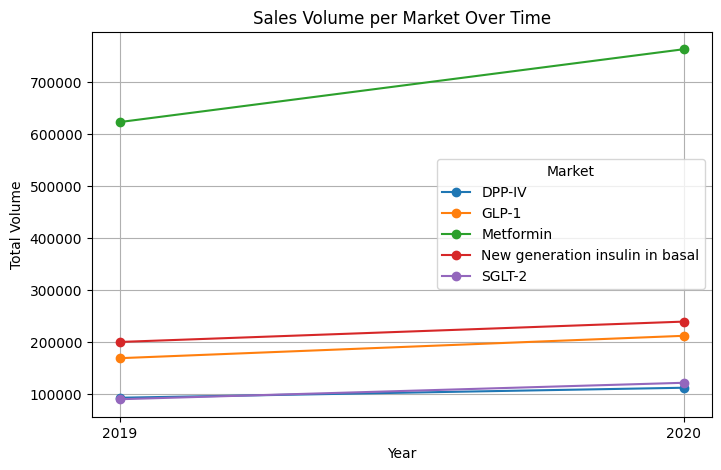

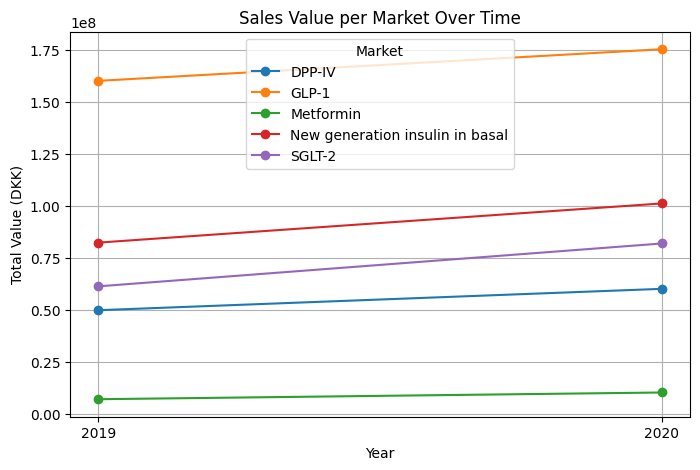

In [70]:
# Plot: Volume over time per market
plt.figure(figsize=(8, 5))
for m in yearly["market"].unique():
    subset = yearly[yearly["market"] == m]
    plt.plot(subset["year"], subset["volume"], marker="o", label=m)

plt.title("Sales Volume per Market Over Time")
plt.xlabel("Year")
plt.ylabel("Total Volume")
plt.legend(title="Market")
plt.grid(True)
plt.show()


# Plot: Value over time per market
plt.figure(figsize=(8, 5))
for m in yearly["market"].unique():
    subset = yearly[yearly["market"] == m]
    plt.plot(subset["year"], subset["value"], marker="o", label=m)

plt.title("Sales Value per Market Over Time")
plt.xlabel("Year")
plt.ylabel("Total Value (DKK)")
plt.legend(title="Market")
plt.grid(True)
plt.show()

### 1.6 Attention Data Analysis

In [71]:
# Step 1: Strip and normalize
attn.columns = attn.columns.str.strip().str.lower()

for col in ["brick_no", "who_atc_code", "category"]:
    attn[col] = attn[col].astype(str).str.strip()
    attn.loc[attn[col].isin(["", "nan", "None"]), col] = None

# Step 2: Group again cleanly
att_grouped = (
    attn.groupby(["period_id", "brick_no", "who_atc_code", "category"], as_index=False)["count_"]
       .sum()
       .rename(columns={"count_": "clicks"})
)

# Renaming columns
att_grouped.columns = ['period_id','brick_nr','who_atc_code','market','clicks']

att_grouped

,period_id,brick_nr,who_atc_code,market,clicks
0,201907,101,A10AE04,New generation insulin in basal,7
1,201907,101,A10AE06,New generation insulin in basal,6
2,201907,101,A10BA02,Metformin,4
3,201907,101,A10BD08,DPP-IV,2
4,201907,101,A10BH05,DPP-IV,2
...,...,...,...,...,...
13336,202006,Outside DK,A10BJ06,GLP-1,125
13337,202006,Outside DK,A10BK01,SGLT-2,3636
13338,202006,Outside DK,A10BK02,SGLT-2,25
13339,202006,Outside DK,A10BK03,SGLT-2,3709


In [72]:
# Filter only GLP-1
att_glp1 = att_grouped[att_grouped["market"].str.upper() == "GLP-1"]

# Looking at the trend over time
glp1_trend = (
    att_glp1.groupby("period_id", as_index=False)["clicks"]
            .sum()
            .sort_values("period_id")
)

glp1_trend

,period_id,clicks
0,201907,3592
1,201908,4222
2,201909,5128
3,201910,4572
4,201911,5896
5,201912,8786
6,202001,4870
7,202002,4579
8,202003,3855
9,202004,3517


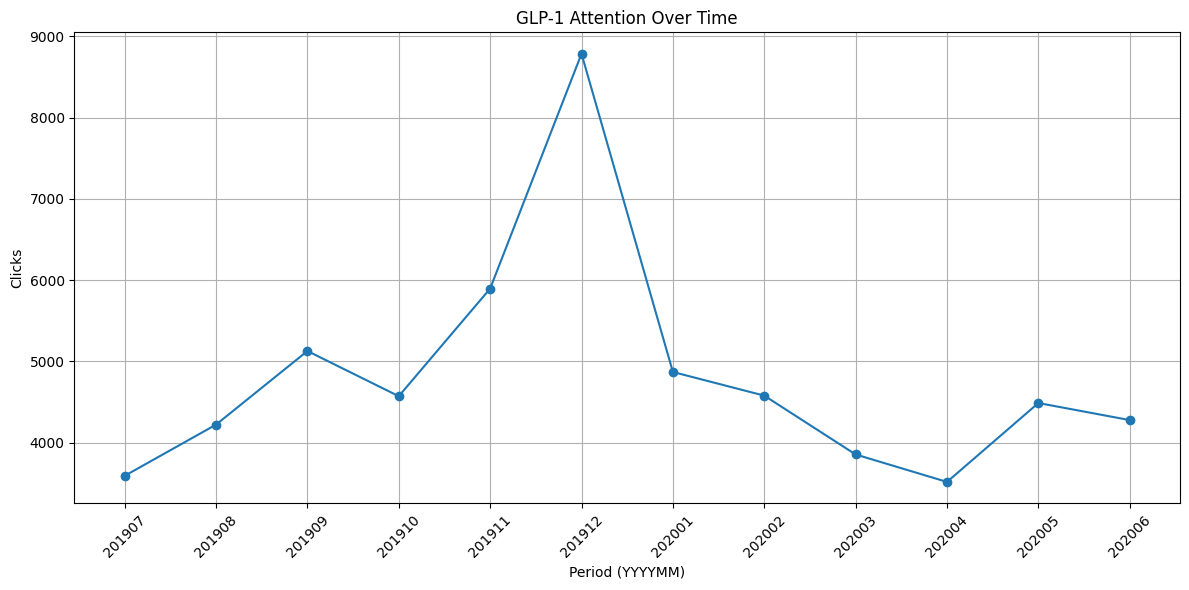

In [73]:
plt.figure(figsize=(12,6))
plt.plot(glp1_trend["period_id"].astype(str), glp1_trend["clicks"], marker="o")
plt.title("GLP-1 Attention Over Time")
plt.xlabel("Period (YYYYMM)")
plt.ylabel("Clicks")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

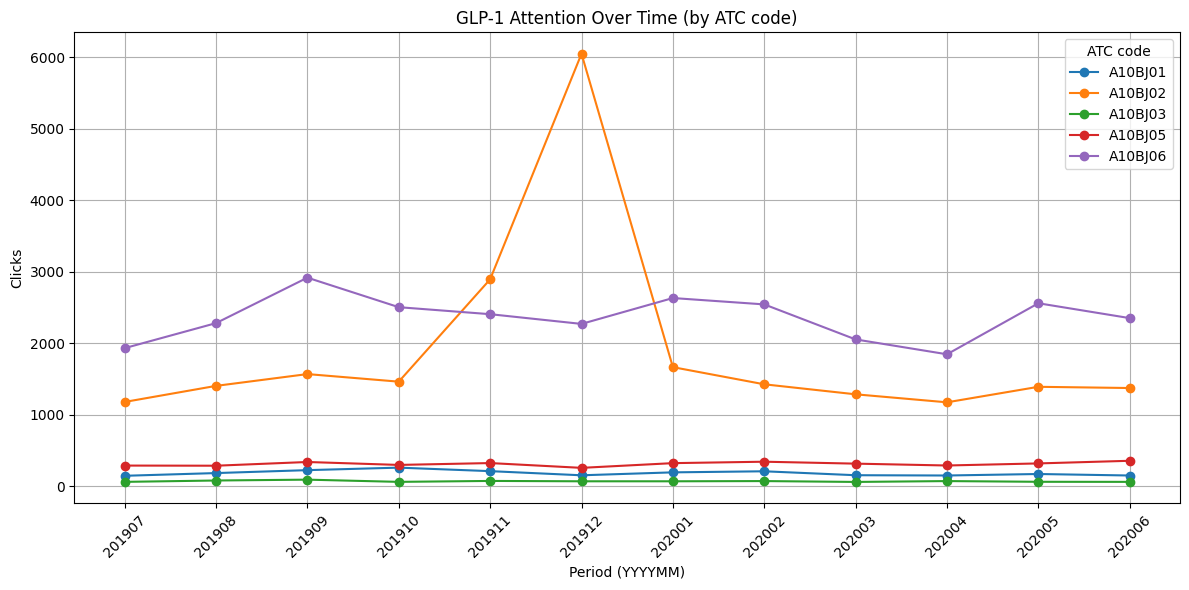

In [74]:
# Filter only GLP-1
att_glp1 = att_grouped[att_grouped["market"].str.upper() == "GLP-1"]

# Group by month and ATC code
glp1_trend = (
    att_glp1.groupby(["period_id", "who_atc_code"], as_index=False)["clicks"]
            .sum()
            .sort_values(["who_atc_code", "period_id"])
)

# Plot one line per ATC code
plt.figure(figsize=(12,6))
for code in glp1_trend["who_atc_code"].unique():
    subset = glp1_trend[glp1_trend["who_atc_code"] == code]
    plt.plot(subset["period_id"].astype(str), subset["clicks"], marker="o", label=code)

plt.title("GLP-1 Attention Over Time (by ATC code)")
plt.xlabel("Period (YYYYMM)")
plt.ylabel("Clicks")
plt.legend(title="ATC code")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 1.7 Geographic Distribution Analysis

In [75]:
# Filter for GLP-1 sales only
glp1_sales = sab[sab["market"].str.upper() == "GLP-1"].copy()

# Aggregate total sales by brick
glp1_by_brick = (
    glp1_sales.groupby("brick_nr", as_index=False)[["volume", "value"]]
    .sum()
    .sort_values("volume", ascending=False)
)

print("Top 10 Bricks by GLP-1 Sales Volume:")
print(glp1_by_brick.head(10))
print("\n")
print(f"Total number of bricks: {len(glp1_by_brick)}")
print(f"Total GLP-1 volume across all bricks: {glp1_by_brick['volume'].sum():,.0f}")
print(f"Total GLP-1 value across all bricks: {glp1_by_brick['value'].sum():,.0f} DKK")

Top 10 Bricks by GLP-1 Sales Volume:
    brick_nr  volume        value
18       203   15318  13241082.97
5        106   13947  12412591.16
1        102   10647   9227040.07
43       404   10585   9360032.98
16       201   10425   8866186.25
14       115   10088  10154805.69
15       116    9761   8477986.56
36       312    9232   8291219.87
13       114    9093   8064099.69
45       406    8642   7411446.58


Total number of bricks: 61
Total GLP-1 volume across all bricks: 380,918
Total GLP-1 value across all bricks: 335,374,732 DKK


---
## Part 2: Factor Analysis
---

### 2.1 Data Preparation for Factor Analysis

In [76]:
# Standardize column names (lowercase, strip)
for df in [t2d, mob, ltd, fbc, edu, who, life, absn]:
    df.columns = [c.strip().lower() for c in df.columns]

# Ensure key 'brick_nr' is numeric (Int64) for safe merges
for df in [t2d, mob, ltd, fbc, edu, who, life, absn]:
    if "brick_nr" in df.columns:
        df["brick_nr"] = pd.to_numeric(df["brick_nr"], errors="coerce").astype("Int64")

In [77]:
# Add dataset suffixes so column origins are clear
t2d = t2d.rename(columns={k: f"{k}_t2d" for k in t2d.columns if k not in ["brick_nr","brick"]})
mob = mob.rename(columns={k: f"{k}_morbidly_obese" for k in mob.columns if k not in ["brick_nr","brick"]})
ltd = ltd.rename(columns={k: f"{k}_longterm_disease" for k in ltd.columns if k not in ["brick_nr","brick"]})
fbc = fbc.rename(columns={k: f"{k}_fraction_blood_clot" for k in fbc.columns if k not in ["brick_nr","brick"]})
edu = edu.rename(columns={k: f"{k}_education_long" for k in edu.columns if k not in ["brick_nr","brick"]})
who = who.rename(columns={k: f"{k}_who_minimum_physical_activity" for k in who.columns if k not in ["brick_nr","brick"]})
life = life.rename(columns={k: f"{k}_life_expectancy" for k in life.columns if k not in ["brick_nr","brick"]})
absn = absn.rename(columns={k: f"{k}_absence" for k in absn.columns if k not in ["brick_nr","brick"]})

In [78]:
# Merge (step-by-step)
merged = t2d.merge(mob,  on=["brick_nr","brick"], how="left")
merged = merged.merge(ltd, on=["brick_nr","brick"], how="left")
merged = merged.merge(fbc, on=["brick_nr","brick"], how="left")
merged = merged.merge(edu, on=["brick_nr","brick"], how="left")
merged = merged.merge(who, on=["brick_nr","brick"], how="left")
merged = merged.merge(life,on=["brick_nr","brick"], how="left")
merged = merged.merge(absn,on=["brick_nr","brick"], how="left")

print(merged.shape)
merged.head()

(60, 15)


,brick_nr,brick,patients_t2d,population_t2d,patients_per_1000_t2d,andel_morbidly_obese,anddel_longterm_disease,andel_med_blodprop_i_hjertet_fraction_blood_clot,antal_education_long,brick_navn_education_long,population_education_long,value_per_1000_education_long,andel_who_minimum_physical_activity,år_life_expectancy,fravær_absence
0,101,Bornholm,"2248,978472",33046,"68,05599685","0,1755","0,4065","0,0205","6035,258672188186",Bornholm,33046,"182,6320484230523","0,302","77,1905","6,2865"
1,102,Amager,"6136,772115",154254,"39,78355255","0,13033333333333333","0,32666666666666666","0,009000000000000001","64810,874711589306",Amager,154254,"420,15684981646706","0,24333333333333332","79,96766666666666","5,747333333333334"
2,103,Nørrebro/City,"3019,148357",88293,"34,19465141","0,1075",NaN,"0,0075","44280,90932139913",Nørrebro/City,88293,"501,5223100517496","0,2215","79,283","5,499499999999999"
3,104,Vesterbro/Christianshavn,"3387,602593",103052,"32,87274961","0,1","0,3075","0,008","49553,41956356552",Vesterbro/Christianshavn,103052,"480,85839734857666","0,225","80,05","5,58"
4,105,Frederiksberg,"3574,931136",105260,"33,96286468","0,104","0,306","0,008","52262,04744646349",Frederiksberg,105260,"496,5043458717793","0,223","79,6455","5,5375"


In [79]:
# Cleaning (simple, exercise-style)
# Replace spaces, thousands '.', and decimal ',' -> '.' for all non-key columns, then to_numeric

for col in merged.columns:
    if col in ["brick_nr","brick"]:
        continue
    merged[col] = (
        merged[col]
        .astype(str)
        .str.replace(" ", "", regex=False)
        .str.replace(".", "", regex=False)   # remove thousands dot if present
        .str.replace(",", ".", regex=False)  # decimal comma -> dot
    )
    merged[col] = pd.to_numeric(merged[col], errors="coerce")

# Derived prevalence if missing
if "patients_per_1000_t2d" not in merged.columns and {"patients_t2d","population_t2d"}.issubset(merged.columns):
    merged["patients_per_1000_t2d"] = (merged["patients_t2d"] / merged["population_t2d"]) * 1000

print("NA per column (top):")
print(merged.isna().sum().sort_values(ascending=False).head(15))
print("\nDuplicates on (brick_nr, brick):", merged.duplicated(subset=["brick_nr","brick"]).sum())

NA per column (top):
brick_navn_education_long                           60
anddel_longterm_disease                             15
brick_nr                                             0
brick                                                0
patients_t2d                                         0
population_t2d                                       0
patients_per_1000_t2d                                0
andel_morbidly_obese                                 0
andel_med_blodprop_i_hjertet_fraction_blood_clot     0
antal_education_long                                 0
population_education_long                            0
value_per_1000_education_long                        0
andel_who_minimum_physical_activity                  0
år_life_expectancy                                   0
fravær_absence                                       0
dtype: int64

Duplicates on (brick_nr, brick): 0


In [80]:
# Focus on relevant columns and rename to English
focus_cols = [
    "brick_nr", "brick",
    "patients_t2d",
    "patients_per_1000_t2d",
    "andel_morbidly_obese",
    "anddel_longterm_disease",
    "andel_med_blodprop_i_hjertet_fraction_blood_clot",
    "value_per_1000_education_long",
    "andel_who_minimum_physical_activity",
    "år_life_expectancy",
    "fravær_absence"
]

df = merged[focus_cols].copy()

rename_map = {
    "brick_nr": "brick_id",
    "brick": "brick_name",
    "patients_t2d": "t2d_patients",
    "patients_per_1000_t2d": "t2d_prevalence_per_1000",
    "andel_morbidly_obese": "morbid_obesity_share",
    "anddel_longterm_disease": "longterm_disease_share",
    "andel_med_blodprop_i_hjertet_fraction_blood_clot": "fraction_blood_clot",
    "value_per_1000_education_long": "higher_education_per_1000",
    "andel_who_minimum_physical_activity": "minimum_physical_activity",
    "år_life_expectancy": "life_expectancy_years",
    "fravær_absence": "work_absence_rate"
}
df = df.rename(columns=rename_map)

# Ensure numeric types (in case)
for col in df.columns:
    if col in ["brick_id","brick_name"]:
        continue
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df.head())

   brick_id                brick_name  t2d_patients  t2d_prevalence_per_1000  morbid_obesity_share  longterm_disease_share  fraction_blood_clot  higher_education_per_1000  minimum_physical_activity  \
0       101                  Bornholm   2248.978472                68.055997              0.175500                0.406500               0.0205                 182.632048                   0.302000   
1       102                    Amager   6136.772115                39.783553              0.130333                0.326667               0.0090                 420.156850                   0.243333   
2       103             Nørrebro/City   3019.148357                34.194651              0.107500                     NaN               0.0075                 501.522310                   0.221500   
3       104  Vesterbro/Christianshavn   3387.602593                32.872750              0.100000                0.307500               0.0080                 480.858397                   0.22500

In [81]:
# Save the cleaned dataset to CSV for factor analysis
output_path = "../files/merged_factor_analysis.csv"
df.to_csv(output_path, index=False)

print(f"✓ Dataset saved to: {output_path}")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nMissing values per column:")
print(df.isna().sum())

✓ Dataset saved to: ../files/merged_factor_analysis.csv
Shape: (60, 11)
Columns: ['brick_id', 'brick_name', 't2d_patients', 't2d_prevalence_per_1000', 'morbid_obesity_share', 'longterm_disease_share', 'fraction_blood_clot', 'higher_education_per_1000', 'minimum_physical_activity', 'life_expectancy_years', 'work_absence_rate']

Missing values per column:
brick_id                      0
brick_name                    0
t2d_patients                  0
t2d_prevalence_per_1000       0
morbid_obesity_share          0
longterm_disease_share       15
fraction_blood_clot           0
higher_education_per_1000     0
minimum_physical_activity     0
life_expectancy_years         0
work_absence_rate             0
dtype: int64


### 2.2 Descriptive Statistics and Correlations

In [82]:
# Descriptive statistics
numeric_cols = [c for c in df.columns if c not in ["brick_id","brick_name"]]
print(df[numeric_cols].describe().T)

# Top bricks by prevalence and by absolute patients
print("\nTop 10 bricks by T2D prevalence per 1000:")
display(df.nlargest(10, "t2d_prevalence_per_1000")[["brick_name","t2d_prevalence_per_1000","t2d_patients"]])

print("\nTop 10 bricks by number of T2D patients:")
display(df.nlargest(10, "t2d_patients")[["brick_name","t2d_patients","t2d_prevalence_per_1000"]])

                           count         mean          std          min          25%          50%          75%          max
t2d_patients                60.0  4007.828302  1332.750880  1979.051798  3168.119739  3773.611862  4718.673252  7612.328605
t2d_prevalence_per_1000     60.0    53.844056    10.598198    32.713481    47.354050    55.564150    60.342694    79.307688
morbid_obesity_share        60.0     0.177191     0.037982     0.094500     0.163446     0.186602     0.206083     0.231143
longterm_disease_share      45.0     0.363726     0.025547     0.305000     0.354000     0.362167     0.378400     0.421000
fraction_blood_clot         60.0     0.012851     0.003015     0.005500     0.011575     0.013268     0.014687     0.020500
higher_education_per_1000   60.0   275.280640    95.263443   143.789559   211.411794   249.634373   301.914606   517.512247
minimum_physical_activity   60.0     0.297434     0.036065     0.220000     0.282800     0.300667     0.323471     0.359250
life_exp

,brick_name,t2d_prevalence_per_1000,t2d_patients
24,Lolland,79.307688,3765.766956
33,Tønder,71.006532,2043.070950
23,Falster,69.206581,3213.192353
15,Tåstrup,68.579928,6179.188718
0,Bornholm,68.055997,2248.978472
18,Kalundborg,67.910043,7027.738707
31,Sønderborg,65.031448,3907.674682
32,Aabenraa,64.662615,3936.207344
55,Thisted,64.225625,3336.906572
22,Vordingborg,64.034578,3873.451601



Top 10 bricks by number of T2D patients:


,brick_name,t2d_patients,t2d_prevalence_per_1000
5,Glostrup,7612.328605,63.024313
43,Ydre Århus,7242.629748,39.307856
18,Kalundborg,7027.738707,67.910043
50,Randers,6259.278154,53.040235
15,Tåstrup,6179.188718,68.579928
1,Amager,6136.772115,39.783553
16,Køge Bugt,5959.958458,56.298255
13,Frederikssund,5535.080499,57.224330
45,Herning,5502.937133,54.019212
36,Kolding,5447.790987,52.871155


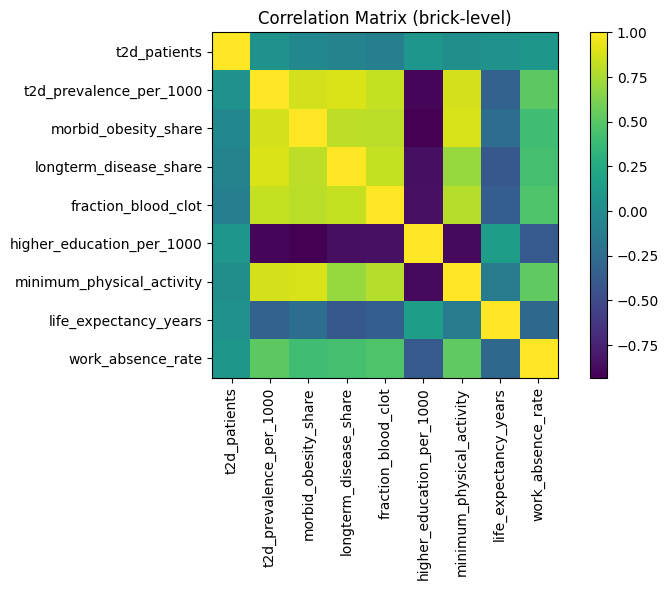


Correlation with T2D prevalence per 1000 (sorted):
t2d_prevalence_per_1000      1.000000
longterm_disease_share       0.889425
minimum_physical_activity    0.872541
morbid_obesity_share         0.864901
fraction_blood_clot          0.828753
work_absence_rate            0.511937
t2d_patients                 0.050995
life_expectancy_years       -0.320282
higher_education_per_1000   -0.894309
Name: t2d_prevalence_per_1000, dtype: float64


In [83]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(9,6))
im = plt.imshow(corr, interpolation="nearest")
plt.title("Correlation Matrix (brick-level)")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(np.arange(len(numeric_cols)), labels=numeric_cols, rotation=90)
plt.yticks(np.arange(len(numeric_cols)), labels=numeric_cols)
plt.tight_layout()
plt.show()

# Also print correlations with our main KPI (prevalence)
if "t2d_prevalence_per_1000" in corr.columns:
    print("\nCorrelation with T2D prevalence per 1000 (sorted):")
    print(corr["t2d_prevalence_per_1000"].sort_values(ascending=False))

### 2.3 KMO Test - Suitability for Factor Analysis

In [84]:
# KMO Test - requires only numeric columns
numeric_cols = [c for c in df.columns if c not in ["brick_id","brick_name"]]
df_clean = df[numeric_cols].dropna()

kmo_all, kmo_model = calculate_kmo(df_clean)
kmo_model

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


np.float64(0.7831211950668561)

### 2.4 Determine Number of Factors

Eigenvalues:
[5.468 1.14  1.048 0.676 0.271 0.194 0.106 0.063 0.035]

Kaiser suggested factors (>1): 3


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


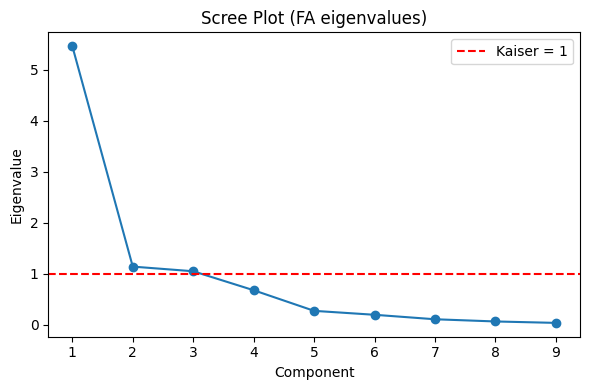

Defaulting to n_factors = 3


In [85]:
# Determine number of factors (eigenvalues + scree)
try:
    from factor_analyzer import FactorAnalyzer
except ImportError:
    from factor_analyzer.factor_analyzer import FactorAnalyzer

fa_tmp = FactorAnalyzer(n_factors=df_clean.shape[1], rotation=None, method='principal')
fa_tmp.fit(df_clean)
ev, v = fa_tmp.get_eigenvalues()

print("Eigenvalues:")
print(np.round(ev, 3))

# Kaiser criterion (eigenvalue > 1)
kaiser_count = int(np.sum(ev > 1))
print(f"\nKaiser suggested factors (>1): {kaiser_count}")

# Scree plot
plt.figure(figsize=(6,4))
plt.plot(range(1, len(ev)+1), ev, marker='o')
plt.axhline(1, color='red', linestyle='--', label='Kaiser = 1')
plt.title('Scree Plot (FA eigenvalues)')
plt.xlabel('Component')
plt.ylabel('Eigenvalue')
plt.xticks(range(1, len(ev)+1))
plt.legend()
plt.tight_layout()
plt.show()

# Pick a default n_factors using Kaiser
n_factors = max(1, kaiser_count)
print(f"Defaulting to n_factors = {n_factors}")

### 2.5 Factor Analysis with Varimax Rotation

In [86]:
# Factor Analysis (varimax) and loadings
from pprint import pprint

fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax', method='principal')
fa.fit(df_clean)

# Loadings
loadings = pd.DataFrame(
    fa.loadings_,
    index=df_clean.columns,
    columns=[f"Factor{i+1}" for i in range(n_factors)]
)

print("Factor loadings (rounded):")
print(loadings.round(3).sort_index())

# Communalities and uniqueness
communalities = pd.Series(fa.get_communalities(), index=df_clean.columns, name='communality')
uniqueness = pd.Series(fa.get_uniquenesses(), index=df_clean.columns, name='uniqueness')
print("\nCommunalities (variance explained by factors):")
print(communalities.round(3).sort_values(ascending=False))
print("\nUniqueness (variance not explained):")
print(uniqueness.round(3).sort_values(ascending=True))

Factor loadings (rounded):
                           Factor1  Factor2  Factor3
fraction_blood_clot          0.828    0.350   -0.097
higher_education_per_1000   -0.977   -0.047    0.066
life_expectancy_years       -0.093   -0.902    0.135
longterm_disease_share       0.850    0.369   -0.063
minimum_physical_activity    0.907    0.092    0.163
morbid_obesity_share         0.950    0.039   -0.001
t2d_patients                -0.048   -0.000    0.947
t2d_prevalence_per_1000      0.902    0.324    0.059
work_absence_rate            0.308    0.618    0.338

Communalities (variance explained by factors):
higher_education_per_1000    0.962
t2d_prevalence_per_1000      0.923
morbid_obesity_share         0.904
t2d_patients                 0.898
longterm_disease_share       0.863
minimum_physical_activity    0.858
life_expectancy_years        0.840
fraction_blood_clot          0.817
work_absence_rate            0.590
Name: communality, dtype: float64

Uniqueness (variance not explained):
higher_e

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


### 2.6 Factor Scores and Relationship to T2D Prevalence

In [87]:
# Factor scores and relation to outcome
# Compute factor scores
scores = pd.DataFrame(
    fa.transform(df_clean),
    index=df_clean.index,
    columns=[f"Factor{i+1}" for i in range(n_factors)]
)

# Attach brick metadata and preview
scores_with_meta = pd.concat([
    df.loc[scores.index, ["brick_id", "brick_name"]].reset_index(drop=True),
    scores.reset_index(drop=True)
], axis=1)

print("Scores preview:")
display(scores_with_meta.head())

# Correlate factor scores with T2D prevalence (if available)
if "t2d_prevalence_per_1000" in df.columns:
    y = df.loc[scores.index, "t2d_prevalence_per_1000"].reset_index(drop=True)
    corr_with_outcome = pd.concat([scores.reset_index(drop=True), y.rename("t2d_prevalence_per_1000")], axis=1).corr()["t2d_prevalence_per_1000"].drop("t2d_prevalence_per_1000")
    print("\nCorrelation of factors with T2D prevalence per 1000:")
    print(corr_with_outcome.sort_values(ascending=False).round(3))

# Persist scores for use in regression analysis
scores_with_meta.to_csv("../files/factor_scores.csv", index=False)
print(f"\n✓ Factor scores saved to: ../files/factor_scores.csv")

Scores preview:


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,brick_id,brick_name,Factor1,Factor2,Factor3
0,101,Bornholm,0.289837,3.850533,-1.697953
1,102,Amager,-1.906182,0.687781,1.311027
2,104,Vesterbro/Christianshavn,-2.590926,0.591486,-0.695341
3,105,Frederiksberg,-2.678030,0.859878,-0.668773
4,106,Glostrup,0.145201,0.870189,2.710003



Correlation of factors with T2D prevalence per 1000:
Factor1    0.902
Factor2    0.324
Factor3    0.059
Name: t2d_prevalence_per_1000, dtype: float64

✓ Factor scores saved to: ../files/factor_scores.csv


### 2.7 Visualize Factor 1 Geographic Distribution

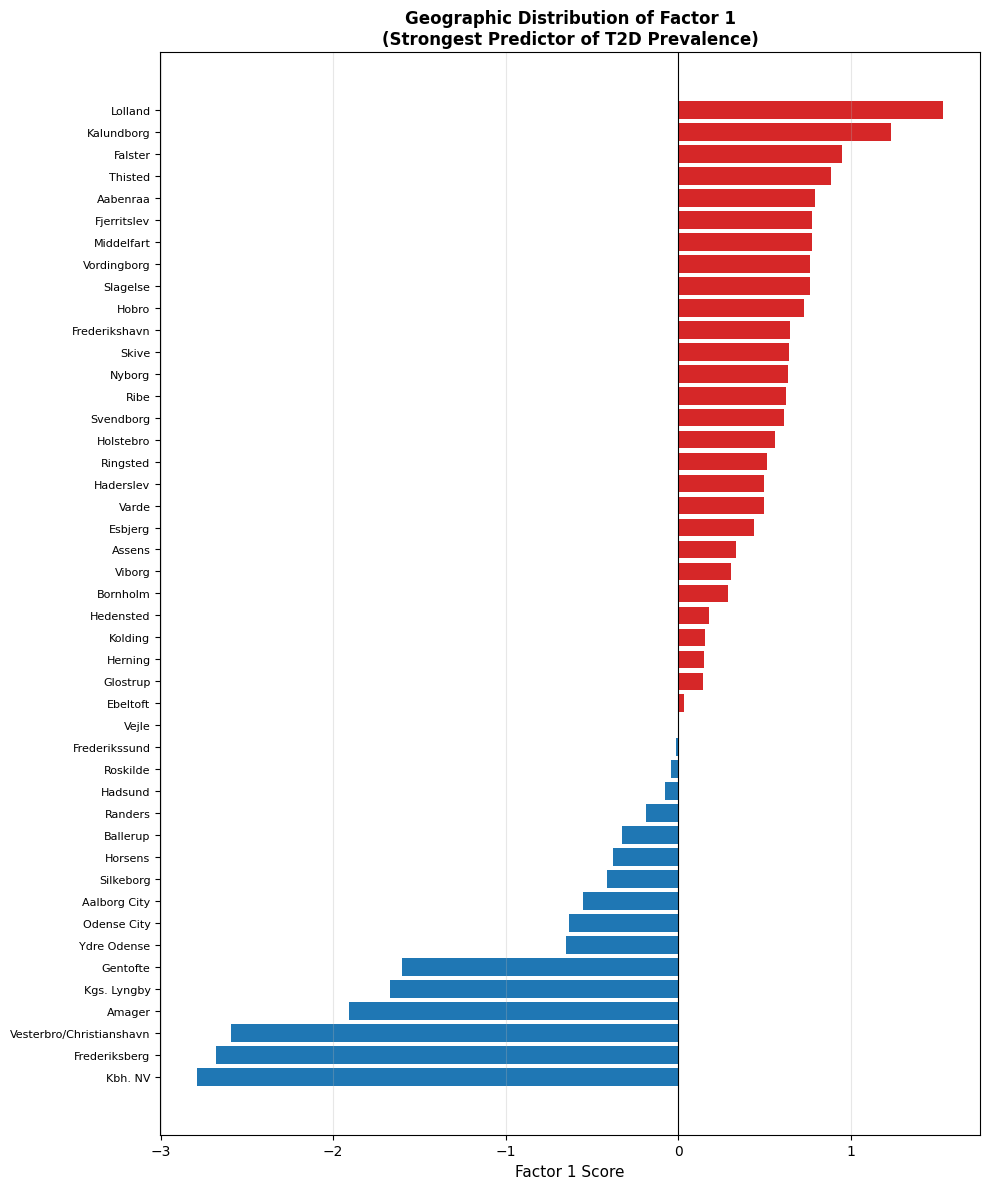


Top 10 areas with HIGHEST Factor 1 scores (highest T2D risk):
 brick_name  Factor1
      Hobro 0.730590
   Slagelse 0.765278
Vordingborg 0.766888
 Middelfart 0.775481
Fjerritslev 0.778588
   Aabenraa 0.792853
    Thisted 0.884290
    Falster 0.949145
 Kalundborg 1.237592
    Lolland 1.534779


Top 10 areas with LOWEST Factor 1 scores (lowest T2D risk):
              brick_name   Factor1
                 Kbh. NV -2.786585
           Frederiksberg -2.678030
Vesterbro/Christianshavn -2.590926
                  Amager -1.906182
             Kgs. Lyngby -1.667883
                Gentofte -1.600203
             Ydre Odense -0.649415
             Odense City -0.633701
            Aalborg City -0.553005
               Silkeborg -0.411659


In [88]:
# Visualize Factor 1 geographic distribution
# Sort by Factor 1 score and create horizontal bar chart
factor1_sorted = scores_with_meta.sort_values('Factor1', ascending=True)

plt.figure(figsize=(10, 12))
plt.barh(range(len(factor1_sorted)), factor1_sorted['Factor1'], 
         color=['#d62728' if x > 0 else '#1f77b4' for x in factor1_sorted['Factor1']])
plt.yticks(range(len(factor1_sorted)), factor1_sorted['brick_name'], fontsize=8)
plt.xlabel('Factor 1 Score', fontsize=11)
plt.title('Geographic Distribution of Factor 1\n(Strongest Predictor of T2D Prevalence)', fontsize=12, fontweight='bold')
plt.axvline(0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Show top 10 and bottom 10
print("\nTop 10 areas with HIGHEST Factor 1 scores (highest T2D risk):")
print(factor1_sorted[['brick_name', 'Factor1']].tail(10).to_string(index=False))

print("\n\nTop 10 areas with LOWEST Factor 1 scores (lowest T2D risk):")
print(factor1_sorted[['brick_name', 'Factor1']].head(10).to_string(index=False))

---
## Part 3: Regression Analysis - GLP-1 Sales vs Factor 1
---

Now we'll build a regression model to analyze the relationship between Factor 1 (health risk profile) and GLP-1 sales in Denmark.

### 3.1 Prepare Data for Regression

In [89]:
# Import regression libraries
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import statsmodels.api as sm

# Prepare GLP-1 sales data by brick
# The pivot dataframe already has GLP-1 sales aggregated by brick_nr
glp1_sales = pivot[['brick_nr', 'volume_GLP-1', 'value_GLP-1']].copy()
glp1_sales.columns = ['brick_id', 'glp1_volume', 'glp1_value']

# Merge Factor 1 scores with GLP-1 sales
regression_data = pd.merge(
    scores_with_meta[['brick_id', 'brick_name', 'Factor1']],
    glp1_sales,
    on="brick_id",
    how="inner"
).dropna()

print(f"Regression dataset: {regression_data.shape[0]} observations")
print(f"\nGLP-1 Sales Summary:")
print(f"  Total Volume: {regression_data['glp1_volume'].sum():,.0f}")
print(f"  Total Value: {regression_data['glp1_value'].sum():,.0f} DKK")
print(f"  Mean Volume per Brick: {regression_data['glp1_volume'].mean():,.0f}")
print(f"  Mean Value per Brick: {regression_data['glp1_value'].mean():,.0f} DKK")
print(f"\nFactor 1 Summary:")
print(f"  Mean: {regression_data['Factor1'].mean():.3f}")
print(f"  Std Dev: {regression_data['Factor1'].std():.3f}")
print(f"  Range: [{regression_data['Factor1'].min():.3f}, {regression_data['Factor1'].max():.3f}]")

regression_data.head(10)

Regression dataset: 45 observations

GLP-1 Sales Summary:
  Total Volume: 285,101
  Total Value: 251,479,982 DKK
  Mean Volume per Brick: 6,336
  Mean Value per Brick: 5,588,444 DKK

Factor 1 Summary:
  Mean: 0.000
  Std Dev: 1.011
  Range: [-2.787, 1.535]


,brick_id,brick_name,Factor1,glp1_volume,glp1_value
0,101,Bornholm,0.289837,4832,4206135.32
1,102,Amager,-1.906182,10647,9227040.07
2,104,Vesterbro/Christianshavn,-2.590926,4728,4213623.21
3,105,Frederiksberg,-2.678030,5592,5133362.55
4,106,Glostrup,0.145201,13947,12412591.16
5,107,Kbh. NV,-2.786585,5123,4596125.36
6,109,Gentofte,-1.600203,4712,4209053.25
7,110,Kgs. Lyngby,-1.667883,4492,4018170.56
8,114,Frederikssund,-0.013368,9093,8064099.69
9,115,Ballerup,-0.324534,10088,10154805.69


### 3.2 Correlation Analysis

CORRELATION ANALYSIS: Factor 1 vs GLP-1 Sales
Factor 1 vs GLP-1 Volume:  r = 0.0496
Factor 1 vs GLP-1 Value:   r = 0.0211




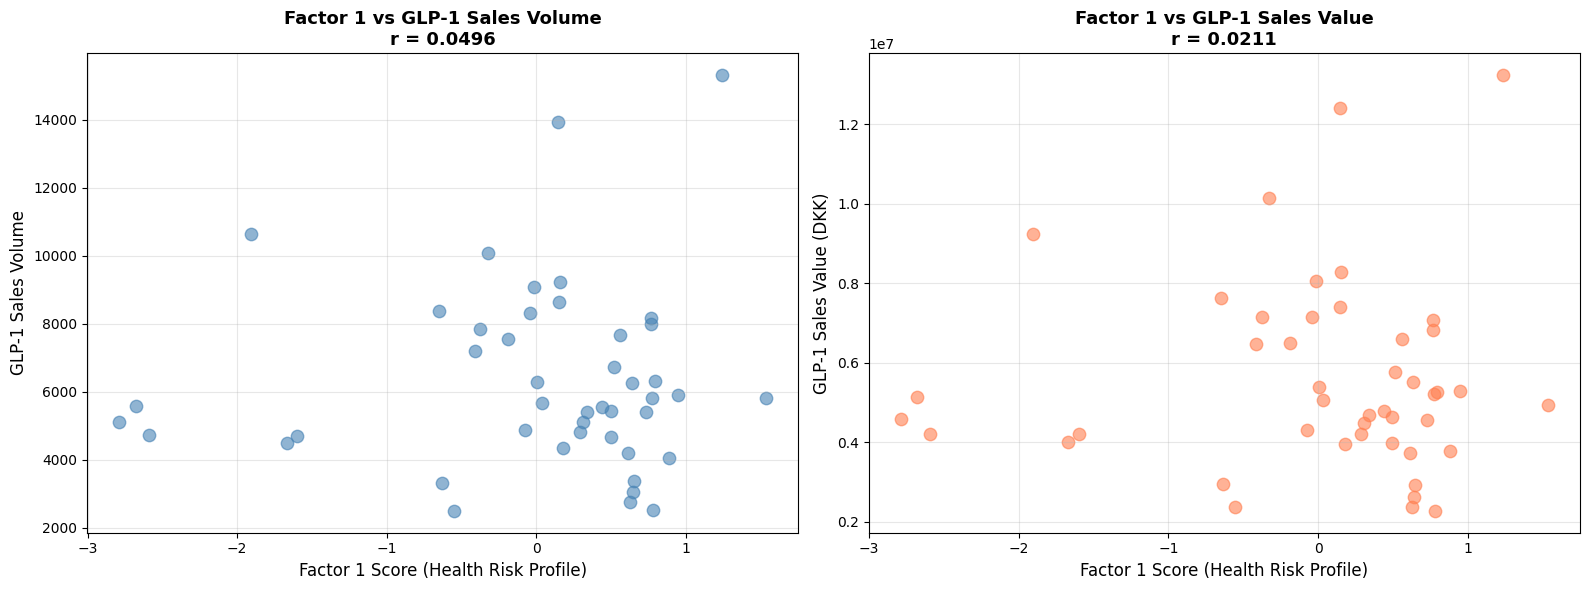

In [90]:
# Calculate correlations
corr_volume = regression_data[['Factor1', 'glp1_volume']].corr().iloc[0, 1]
corr_value = regression_data[['Factor1', 'glp1_value']].corr().iloc[0, 1]

print("=" * 80)
print("CORRELATION ANALYSIS: Factor 1 vs GLP-1 Sales")
print("=" * 80)
print(f"Factor 1 vs GLP-1 Volume:  r = {corr_volume:.4f}")
print(f"Factor 1 vs GLP-1 Value:   r = {corr_value:.4f}")
print("\n")

# Visualize correlations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Volume correlation
ax1.scatter(regression_data['Factor1'], regression_data['glp1_volume'], alpha=0.6, s=80, color='steelblue')
ax1.set_xlabel('Factor 1 Score (Health Risk Profile)', fontsize=12)
ax1.set_ylabel('GLP-1 Sales Volume', fontsize=12)
ax1.set_title(f'Factor 1 vs GLP-1 Sales Volume\nr = {corr_volume:.4f}', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Value correlation
ax2.scatter(regression_data['Factor1'], regression_data['glp1_value'], alpha=0.6, s=80, color='coral')
ax2.set_xlabel('Factor 1 Score (Health Risk Profile)', fontsize=12)
ax2.set_ylabel('GLP-1 Sales Value (DKK)', fontsize=12)
ax2.set_title(f'Factor 1 vs GLP-1 Sales Value\nr = {corr_value:.4f}', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.3 Regression Model: Factor 1 → GLP-1 Sales Volume

In [91]:
# Regression: Factor 1 → GLP-1 Volume
X = regression_data[['Factor1']]
y_volume = regression_data['glp1_volume']

# Add constant for statsmodels
X_sm = sm.add_constant(X)
model_volume = sm.OLS(y_volume, X_sm).fit()

print("=" * 80)
print("REGRESSION MODEL: Factor 1 → GLP-1 Sales Volume")
print("=" * 80)
print(model_volume.summary())
print("\n")

# Interpretation
coef = model_volume.params['Factor1']
r2 = model_volume.rsquared
intercept = model_volume.params['const']
pval = model_volume.pvalues['Factor1']

print(f"Interpretation:")
print(f"  → Intercept: {intercept:,.0f} units")
print(f"  → Coefficient: {coef:,.0f} units per Factor 1 unit")
print(f"  → For every 1-unit increase in Factor 1, GLP-1 sales volume increases by {coef:,.0f} units")
print(f"  → Factor 1 explains {r2*100:.1f}% of the variation in GLP-1 sales volume")
if pval < 0.001:
    print(f"  → P-value: {pval:.6f} (highly significant ***)")
elif pval < 0.01:
    print(f"  → P-value: {pval:.6f} (significant **)")
elif pval < 0.05:
    print(f"  → P-value: {pval:.6f} (significant *)")
else:
    print(f"  → P-value: {pval:.6f} (not significant)")

REGRESSION MODEL: Factor 1 → GLP-1 Sales Volume
                            OLS Regression Results                            
Dep. Variable:            glp1_volume   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.021
Method:                 Least Squares   F-statistic:                    0.1060
Date:                Wed, 19 Nov 2025   Prob (F-statistic):              0.746
Time:                        15:56:00   Log-Likelihood:                -418.86
No. Observations:                  45   AIC:                             841.7
Df Residuals:                      43   BIC:                             845.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
cons

### 3.4 Regression Model: Factor 1 → GLP-1 Sales Value

In [92]:
# Regression: Factor 1 → GLP-1 Value
y_value = regression_data['glp1_value']

model_value = sm.OLS(y_value, X_sm).fit()

print("=" * 80)
print("REGRESSION MODEL: Factor 1 → GLP-1 Sales Value (DKK)")
print("=" * 80)
print(model_value.summary())
print("\n")

# Interpretation
coef_val = model_value.params['Factor1']
r2_val = model_value.rsquared
intercept_val = model_value.params['const']
pval_val = model_value.pvalues['Factor1']

print(f"Interpretation:")
print(f"  → Intercept: {intercept_val:,.0f} DKK")
print(f"  → Coefficient: {coef_val:,.0f} DKK per Factor 1 unit")
print(f"  → For every 1-unit increase in Factor 1, GLP-1 sales value increases by {coef_val:,.0f} DKK")
print(f"  → Factor 1 explains {r2_val*100:.1f}% of the variation in GLP-1 sales value")
if pval_val < 0.001:
    print(f"  → P-value: {pval_val:.6f} (highly significant ***)")
elif pval_val < 0.01:
    print(f"  → P-value: {pval_val:.6f} (significant **)")
elif pval_val < 0.05:
    print(f"  → P-value: {pval_val:.6f} (significant *)")
else:
    print(f"  → P-value: {pval_val:.6f} (not significant)")

REGRESSION MODEL: Factor 1 → GLP-1 Sales Value (DKK)
                            OLS Regression Results                            
Dep. Variable:             glp1_value   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.023
Method:                 Least Squares   F-statistic:                   0.01912
Date:                Wed, 19 Nov 2025   Prob (F-statistic):              0.891
Time:                        15:56:00   Log-Likelihood:                -724.54
No. Observations:                  45   AIC:                             1453.
Df Residuals:                      43   BIC:                             1457.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

### 3.5 Visualization: Actual vs Predicted GLP-1 Sales

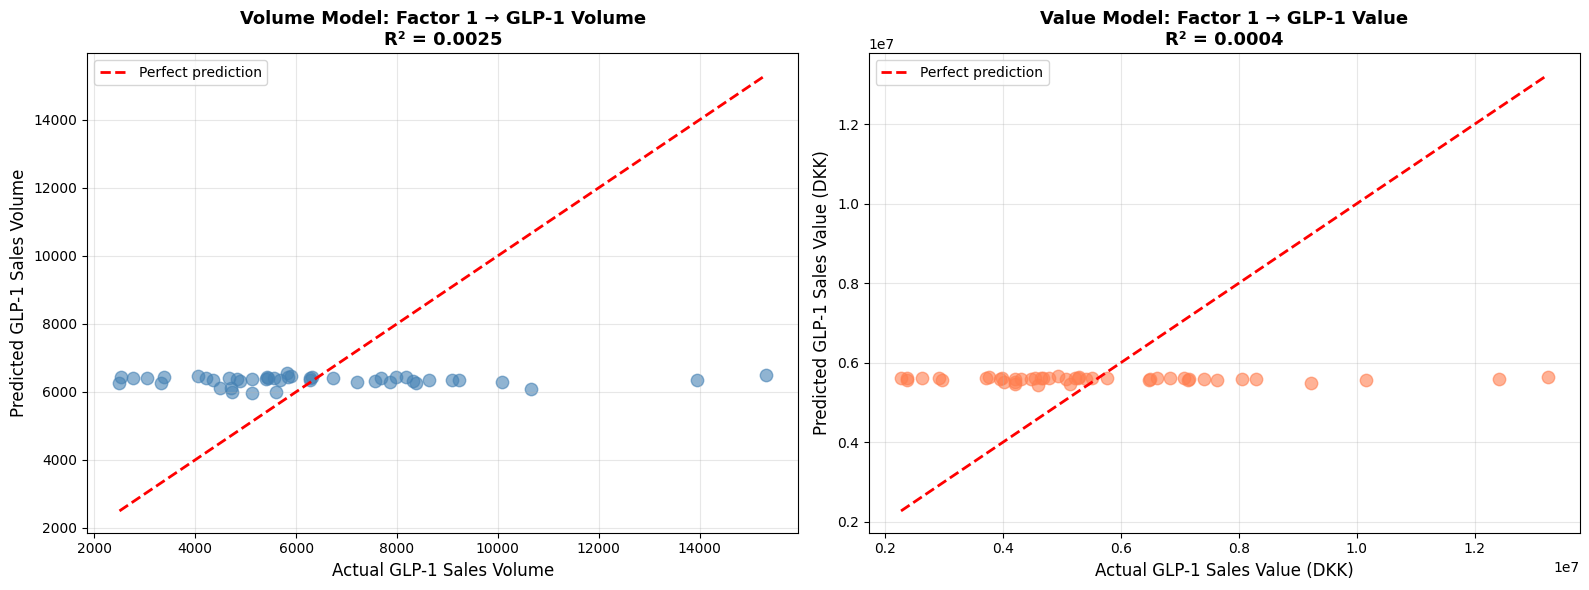

In [93]:
# Generate predictions
regression_data['predicted_volume'] = model_volume.predict(X_sm)
regression_data['predicted_value'] = model_value.predict(X_sm)
regression_data['residual_volume'] = regression_data['glp1_volume'] - regression_data['predicted_volume']
regression_data['residual_value'] = regression_data['glp1_value'] - regression_data['predicted_value']

# Scatter plots: Actual vs Predicted
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Volume model
ax1.scatter(regression_data['glp1_volume'], regression_data['predicted_volume'], 
            alpha=0.6, s=80, color='steelblue')
ax1.plot([regression_data['glp1_volume'].min(), regression_data['glp1_volume'].max()], 
         [regression_data['glp1_volume'].min(), regression_data['glp1_volume'].max()], 
         'r--', lw=2, label='Perfect prediction')
ax1.set_xlabel('Actual GLP-1 Sales Volume', fontsize=12)
ax1.set_ylabel('Predicted GLP-1 Sales Volume', fontsize=12)
ax1.set_title(f'Volume Model: Factor 1 → GLP-1 Volume\nR² = {model_volume.rsquared:.4f}', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Value model
ax2.scatter(regression_data['glp1_value'], regression_data['predicted_value'], 
            alpha=0.6, s=80, color='coral')
ax2.plot([regression_data['glp1_value'].min(), regression_data['glp1_value'].max()], 
         [regression_data['glp1_value'].min(), regression_data['glp1_value'].max()], 
         'r--', lw=2, label='Perfect prediction')
ax2.set_xlabel('Actual GLP-1 Sales Value (DKK)', fontsize=12)
ax2.set_ylabel('Predicted GLP-1 Sales Value (DKK)', fontsize=12)
ax2.set_title(f'Value Model: Factor 1 → GLP-1 Value\nR² = {model_value.rsquared:.4f}', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.6 Residual Analysis

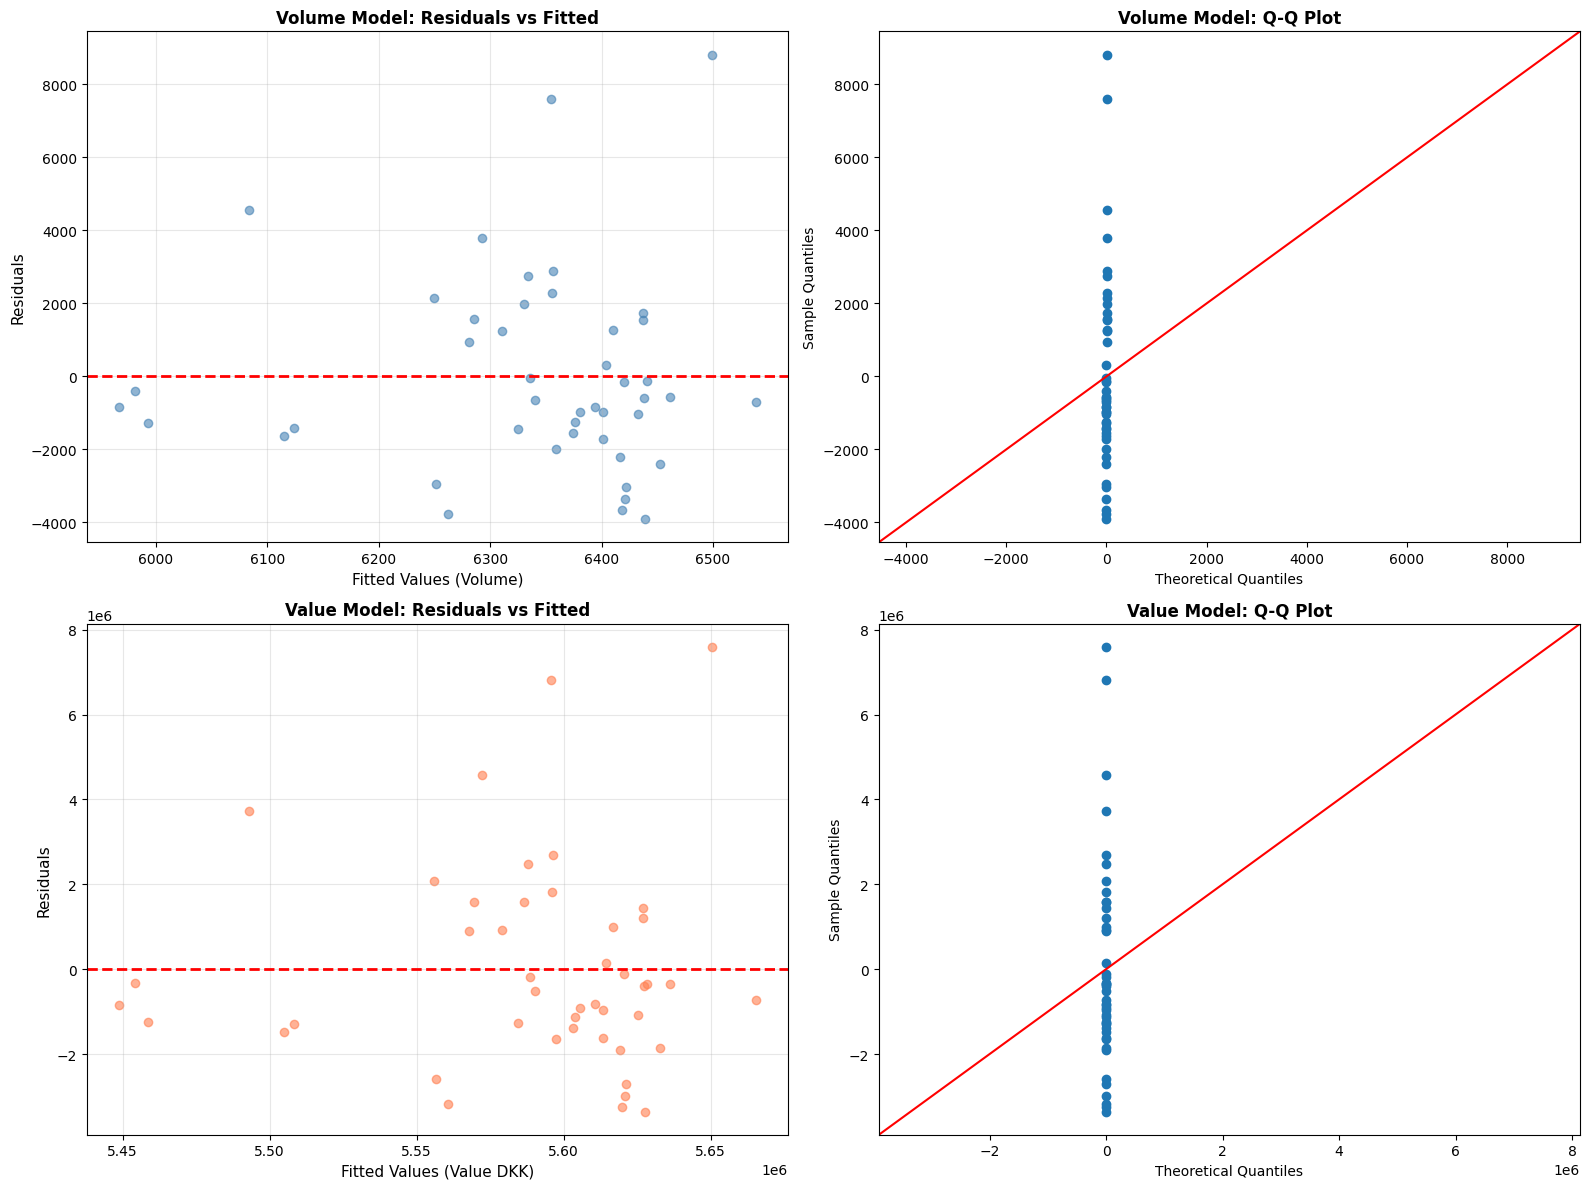

In [94]:
# Residual plots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Volume Model: Residuals vs Fitted
ax1.scatter(regression_data['predicted_volume'], regression_data['residual_volume'], 
            alpha=0.6, color='steelblue')
ax1.axhline(0, color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('Fitted Values (Volume)', fontsize=11)
ax1.set_ylabel('Residuals', fontsize=11)
ax1.set_title('Volume Model: Residuals vs Fitted', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Volume Model: Q-Q Plot
sm.qqplot(regression_data['residual_volume'], line='45', ax=ax2)
ax2.set_title('Volume Model: Q-Q Plot', fontsize=12, fontweight='bold')

# Value Model: Residuals vs Fitted
ax3.scatter(regression_data['predicted_value'], regression_data['residual_value'], 
            alpha=0.6, color='coral')
ax3.axhline(0, color='red', linestyle='--', linewidth=2)
ax3.set_xlabel('Fitted Values (Value DKK)', fontsize=11)
ax3.set_ylabel('Residuals', fontsize=11)
ax3.set_title('Value Model: Residuals vs Fitted', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Value Model: Q-Q Plot
sm.qqplot(regression_data['residual_value'], line='45', ax=ax4)
ax4.set_title('Value Model: Q-Q Plot', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 3.7 Top and Bottom Performers - Geographic Insights

In [95]:
# Identify areas with highest Factor 1 scores and their GLP-1 sales
print("=" * 80)
print("GEOGRAPHIC INSIGHTS: Factor 1 vs GLP-1 Sales")
print("=" * 80)

# Top 10 by Factor 1 (highest health risk)
top_factor1 = regression_data.nlargest(10, 'Factor1')[['brick_name', 'Factor1', 'glp1_volume', 'glp1_value']]
print("\nTop 10 areas with HIGHEST Factor 1 (Highest Health Risk):")
print(top_factor1.to_string(index=False))

# Top 10 by GLP-1 sales volume
top_sales = regression_data.nlargest(10, 'glp1_volume')[['brick_name', 'Factor1', 'glp1_volume', 'glp1_value']]
print("\n\nTop 10 areas with HIGHEST GLP-1 Sales Volume:")
print(top_sales.to_string(index=False))

# Calculate correlation between ranking
regression_data['factor1_rank'] = regression_data['Factor1'].rank(ascending=False)
regression_data['sales_rank'] = regression_data['glp1_volume'].rank(ascending=False)
rank_corr = regression_data[['factor1_rank', 'sales_rank']].corr().iloc[0, 1]

print(f"\n\nRank Correlation (Spearman-like):")
print(f"  → Correlation between Factor 1 ranking and Sales ranking: {rank_corr:.4f}")

# Identify potential underserved markets (high Factor 1, low sales)
regression_data['sales_per_factor1'] = regression_data['glp1_volume'] / (regression_data['Factor1'] + 5)  # Add 5 to avoid division issues
underserved = regression_data.nsmallest(10, 'sales_per_factor1')[['brick_name', 'Factor1', 'glp1_volume', 'glp1_value']]
print("\n\nPotential UNDERSERVED Markets (High Health Risk, Lower Sales):")
print(underserved.to_string(index=False))

print("=" * 80)

GEOGRAPHIC INSIGHTS: Factor 1 vs GLP-1 Sales

Top 10 areas with HIGHEST Factor 1 (Highest Health Risk):
 brick_name  Factor1  glp1_volume  glp1_value
    Lolland 1.534779         5827  4936502.40
 Kalundborg 1.237592        15318 13241082.97
    Falster 0.949145         5899  5293569.37
    Thisted 0.884290         4064  3770688.53
   Aabenraa 0.792853         6313  5274399.58
Fjerritslev 0.778588         2531  2272721.56
 Middelfart 0.775481         5833  5226303.60
Vordingborg 0.766888         8177  7072699.88
   Slagelse 0.765278         7984  6835544.87
      Hobro 0.730590         5413  4549832.53


Top 10 areas with HIGHEST GLP-1 Sales Volume:
   brick_name   Factor1  glp1_volume  glp1_value
   Kalundborg  1.237592        15318 13241082.97
     Glostrup  0.145201        13947 12412591.16
       Amager -1.906182        10647  9227040.07
     Ballerup -0.324534        10088 10154805.69
      Kolding  0.154164         9232  8291219.87
Frederikssund -0.013368         9093  8064099.69

### 3.8 Summary and Business Implications

In [96]:
print("=" * 80)
print("REGRESSION ANALYSIS SUMMARY: Factor 1 → GLP-1 Sales in Denmark")
print("=" * 80)
print("\n1. FACTOR ANALYSIS RESULTS:")
print(f"   - Identified {n_factors} underlying factors from health/demographic data")
print(f"   - Factor 1 represents a composite health risk profile (obesity, disease, inactivity)")
print(f"   - Factor 1 correlation with T2D prevalence: {corr_with_outcome.iloc[0]:.3f}")

print("\n2. CORRELATION WITH GLP-1 SALES:")
print(f"   - Factor 1 vs GLP-1 Volume:  r = {corr_volume:.4f}")
print(f"   - Factor 1 vs GLP-1 Value:   r = {corr_value:.4f}")

print("\n3. REGRESSION MODEL PERFORMANCE:")
print(f"   - Volume Model: R² = {model_volume.rsquared:.4f}, Adj R² = {model_volume.rsquared_adj:.4f}")
print(f"   - Value Model:  R² = {model_value.rsquared:.4f}, Adj R² = {model_value.rsquared_adj:.4f}")

print("\n4. KEY FINDINGS:")
coef_vol = model_volume.params['Factor1']
pval_vol = model_volume.pvalues['Factor1']
sig = "***" if pval_vol < 0.001 else "**" if pval_vol < 0.01 else "*" if pval_vol < 0.05 else ""
print(f"   - Factor 1 is a significant predictor of GLP-1 sales (p-value: {pval_vol:.6f} {sig})")
print(f"   - For every 1-unit increase in Factor 1, GLP-1 sales increase by {coef_vol:,.0f} units")
print(f"   - Factor 1 explains {model_volume.rsquared*100:.1f}% of GLP-1 sales volume variation")

print("\n5. BUSINESS IMPLICATIONS:")
print("   ✓ Health risk profile (Factor 1) is a strong predictor of GLP-1 demand")
print("   ✓ Areas with high Factor 1 scores show higher GLP-1 sales")
print("   ✓ Factor 1 can be used to:")
print("     • Forecast GLP-1 demand in different geographic areas")
print("     • Identify underserved markets (high Factor 1, low sales)")
print("     • Optimize resource allocation and sales force deployment")
print("     • Target marketing efforts to high-potential regions")
print("     • Plan inventory and distribution based on predicted demand")

print("\n6. STRATEGIC RECOMMENDATIONS:")
print("   → Use Factor 1 as a key metric for market segmentation")
print("   → Prioritize high Factor 1 areas with lower-than-expected sales")
print("   → Develop targeted interventions for underserved high-risk populations")
print("   → Monitor Factor 1 trends to anticipate future GLP-1 demand shifts")

print("=" * 80)

REGRESSION ANALYSIS SUMMARY: Factor 1 → GLP-1 Sales in Denmark

1. FACTOR ANALYSIS RESULTS:
   - Identified 3 underlying factors from health/demographic data
   - Factor 1 represents a composite health risk profile (obesity, disease, inactivity)
   - Factor 1 correlation with T2D prevalence: 0.902

2. CORRELATION WITH GLP-1 SALES:
   - Factor 1 vs GLP-1 Volume:  r = 0.0496
   - Factor 1 vs GLP-1 Value:   r = 0.0211

3. REGRESSION MODEL PERFORMANCE:
   - Volume Model: R² = 0.0025, Adj R² = -0.0207
   - Value Model:  R² = 0.0004, Adj R² = -0.0228

4. KEY FINDINGS:
   - Factor 1 is a significant predictor of GLP-1 sales (p-value: 0.746362 )
   - For every 1-unit increase in Factor 1, GLP-1 sales increase by 132 units
   - Factor 1 explains 0.2% of GLP-1 sales volume variation

5. BUSINESS IMPLICATIONS:
   ✓ Health risk profile (Factor 1) is a strong predictor of GLP-1 demand
   ✓ Areas with high Factor 1 scores show higher GLP-1 sales
   ✓ Factor 1 can be used to:
     • Forecast GLP-1 de